# Notebook 3: Mitigation via Adaptive Pre-processing Image Restoration

### Overview

This notebook implements and evaluates the first of our two visual mitigation strategies: **Classical Pre-processing Image Restoration**. 

Instead of applying static, hardcoded restoration parameters—which can cause an accuracy penalty on clean or lightly distorted images—we implement **Adaptive Classical Filters**. These filters dynamically scale their window sizes and smoothing intensities on-the-fly based on the active level of corruption. 

We perform a complete, unrestricted dataset-wide evaluation sweep. Every camera distortion (Gaussian Noise, JPEG Compression, and Low-Light) is evaluated against all three tasks:
1. **Low-Level Task:** ORB Keypoint Matching (`ORBMatchingTask`)
2. **Mid-Level Task:** K-Means Semantic Segmentation (`KMeansSegmentationTask`)
3. **High-Level Task:** YOLOv8 Object Detection (`YOLOv8DetectionTask`), evaluated independently for Cars (Class 0), Pedestrians (Class 1), and Cyclists (Class 2).

---

### Core Architectural Upgrades

To ensure a rigorous and standard benchmarking process, this evaluation pipeline includes the following structural upgrades:
* **Cross-Task Evaluation:** Every distortion is evaluated against all three tasks, allowing us to observe cross-task degradation patterns (such as the impact of JPEG blockiness on high-level neural network bounding box regression).
* **Multi-Class Granularity:** The high-level object detection task evaluates both **Precision** and **Recall** independently for all three target classes to capture performance on small-scale minority objects.
* **The Horizontal $1 \times 3$ Plotting Paradigm:** Rather than packing all 15 task-class combinations into a single $5 \times 3$ grid—which renders individual subplots too small to read when scaled down—we generate and save **13 independent horizontal $1 \times 3$ strip images**. Each strip represents a single task or object class side-by-side across the three camera distortions, ensuring high legibility for slides and reports.

## Step 1: System Path Configuration & Module Imports

We configure our local search paths to recognize the `src` folder and import our 
dataset parsing, classical enhancement filters, metrics, and modular task classes.

In [1]:
import sys
from pathlib import Path

# Resolve absolute path to the parent directory of this notebook
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

from src.dataset import KITTIDataset
from src.evaluation import compute_snr
from src.enhancements import restore_noise_bilateral, restore_jpeg_deblocking, restore_lowlight_clahe

from src.tasks.orb_matching import ORBMatchingTask
from src.tasks.kmeans_segmentation import KMeansSegmentationTask
from src.tasks.yolov8_detection import YOLOv8DetectionTask

print("Framework modules successfully loaded.")

Framework modules successfully loaded.


## Step 2: System Subsampling, Alignment & Baseline Caching

To evaluate our pre-processing enhancement filters, we must load the **exact same** systematically sampled validation subset (using a stride of $K=25$) that we evaluated in Notebook 2. This guarantees that:
1. The images we attempt to load from the `processed/distorted/` folder exist.
2. Our distorted vs. enhanced performance curves are computed over the exact same set of physical frames, ensuring statistical consistency.

We instantiate our modular tasks, utilizing:
1. **Low-Level Task:** `ORBMatchingTask` initialized with your calibrated feature budget limit of **`max_features=400`**.
2. **High-Level Task:** `YOLOv8DetectionTask` loaded with your clean-trained Large baseline model (`yolov8_clean.pt`) running at your unified high-resolution inference size of **`960`** to prevent scale mismatches.

In [2]:
# Load the validation dataset
full_dataset = KITTIDataset(root_dir="../data/kitti", split="val")

# Define a systematic stride of 25 matching Notebook 2
stride = 25  
sampled_indices = list(range(0, len(full_dataset), stride))

print(f"Selecting {len(sampled_indices)} systematic samples from {len(full_dataset)} total validation frames.")

# Instantiate task objects (specifying matching 960px resolution and calibrated 400 keypoint limit)
orb_task = ORBMatchingTask(max_features=400)
kmeans_task = KMeansSegmentationTask(k=4)
yolo_task = YOLOv8DetectionTask(model_path="../output/checkpoints/yolov8_clean.pt", imgsz=960)

evaluation_samples = []

print(f"Caching baseline anchors for {len(sampled_indices)} sampled frames...")
for idx in tqdm(sampled_indices, desc="Caching anchors"):
    img, meta = full_dataset.get_sample(idx)
    
    # Extract baseline ORB descriptors
    _, clean_descs = orb_task.run(img)
    meta["baseline_descriptors"] = clean_descs
    
    # Extract baseline K-Means mask as our Pseudo-Ground-Truth (PGT)
    clean_seg_mask = kmeans_task.run(img)
    meta["mask"] = clean_seg_mask
    
    evaluation_samples.append((img, meta))

print(f"Baseline anchors successfully cached for {len(evaluation_samples)} representative frames.")

Dataset split 'val' initialized with 3769 images.
Selecting 151 systematic samples from 3769 total validation frames.
Caching baseline anchors for 151 sampled frames...


Caching anchors: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 151/151 [02:37<00:00,  1.04s/it]

Baseline anchors successfully cached for 151 representative frames.


## Step 3: Defining Dense Sweep Parameters

We define our dense 13-point parameters matching the exact levels used in Notebook 2. 
We also initialize a dictionary to store both the distorted metrics (for reloading) 
and the enhanced metrics.

In [3]:
# Define 13-level dense sweeps matching Notebook 2
sweeps = {
    "GaussianNoise": [
        0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0, 55.0, 60.0
    ],
    "JPEGCompression": [
        100, 90, 80, 70, 60, 50, 40, 30, 20, 15, 10, 5, 1
    ],
    "LowLight": [
        1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 4.0, 4.5
    ]
}

# Mapping of distortion name to its corresponding pre-processing enhancement function
restoration_funcs = {
    "GaussianNoise": restore_noise_bilateral,
    "JPEGCompression": restore_jpeg_deblocking,
    "LowLight": restore_lowlight_clahe
}

# Nested dictionary to store results
# Expanded to track both Recall and Precision for all classes continuously for distorted and enhanced
results = {
    dist_name: {lvl: {
        "snr_dist": [], "snr_enh": [],
        "orb_dist": [], "orb_enh": [],
        "kmeans_dist": [], "kmeans_enh": [],
        "yolo_dist": [], "yolo_enh": [],
        "yolo_dist_prec": [], "yolo_enh_prec": [],
        "yolo_dist_ped": [], "yolo_enh_ped": [],
        "yolo_dist_ped_prec": [], "yolo_enh_ped_prec": [],
        "yolo_dist_cyc": [], "yolo_enh_cyc": [],
        "yolo_dist_cyc_prec": [], "yolo_enh_cyc_prec": []
    } for lvl in lvls} for dist_name, lvls in sweeps.items()
}

print("Sweeps and multi-class metric stores successfully configured.")

Sweeps and multi-class metric stores successfully configured.


## Step 4: Dataset-Wide Multi-Task and Multi-Class Evaluation Sweep

In this step, we execute the comprehensive, dataset-wide evaluation sweep over our systematically sampled validation subset. To ensure statistical stability, the loop processes 151 representative road scenes (using a fixed stride of $K=25$ across the validation set).

### Processing Mechanics:
For each sample, camera distortion, and sweep level:
1. **Load Distorted Image:** Retrieve the distorted image generated in Notebook 2.
2. **Apply Restoration:** Pass the image through the respective adaptive restoration filter:
   - **Bilateral Filtering (`restore_noise_bilateral`)** with `estimated_sigma=lvl` to preserve edges while dampening noise grain.
   - **Deblocking Filtering (`restore_jpeg_deblocking`)** with `estimated_quality=lvl` to smooth out compression boundaries.
   - **CLAHE Equalization (`restore_lowlight_clahe`)** utilizing dual-stage gamma correction and contrast optimization.
3. **Calculate SNR:** Compute the physical Signal-to-Noise Ratio (SNR in dB) for both distorted and enhanced inputs relative to the original clean baseline.
4. **Evaluate All Tasks:** Measure performance across ORB matching, K-Means segmentation, and multi-class YOLOv8 recall and precision. All output metrics are recorded continuously in the nested `results` database.

In [8]:
import os
import torch
import cv2

# Diagnostic check to verify GPU availability
print(f"PyTorch CUDA Available: {torch.cuda.is_available()}")

# 8 concurrent workers offload YOLO tasks to the GPU.
# The host CPU limits are kept at 3 threads per worker (24 cores total) 
# to handle background I/O, ORB, and K-Means without context thrashing.
num_workers = 8
torch.set_num_threads(3)
cv2.setNumThreads(0)

# Limit underlying CPU algebra libraries to keep the host CPU stable
os.environ["OMP_NUM_THREADS"] = "3"
os.environ["MKL_NUM_THREADS"] = "3"
os.environ["OPENBLAS_NUM_THREADS"] = "3"
os.environ["VECLIB_MAXIMUM_THREADS"] = "3"
os.environ["NUMEXPR_NUM_THREADS"] = "3"

from pathlib import Path
import json
import numpy as np
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

dist_root = Path("../data/kitti/processed/distorted")
enh_root = Path("../data/kitti/processed/enhanced")

# Explicitly define sweeps so Step 4 is fully self-contained on restart
sweeps = {
    "GaussianNoise": [0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0, 55.0, 60.0],
    "JPEGCompression": [100, 90, 80, 70, 60, 50, 40, 30, 20, 15, 10, 5, 1],
    "LowLight": [1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 4.0, 4.5]
}

# Re-initialize the comprehensive nested metrics database
results = {
    dist_name: {lvl: {
        "snr_dist": [], "snr_enh": [],
        "orb_dist": [], "orb_enh": [],
        "kmeans_dist": [], "kmeans_enh": [],
        "yolo_dist": [], "yolo_enh": [],                 # Car Recall
        "yolo_dist_prec": [], "yolo_enh_prec": [],       # Car Precision
        "yolo_dist_ped": [], "yolo_enh_ped": [],         # Pedestrian Recall
        "yolo_dist_ped_prec": [], "yolo_enh_ped_prec": [], # Pedestrian Precision
        "yolo_dist_cyc": [], "yolo_enh_cyc": [],         # Cyclist Recall
        "yolo_dist_cyc_prec": [], "yolo_enh_cyc_prec": []  # Cyclist Precision
    } for lvl in lvls} for dist_name, lvls in sweeps.items()
}

def process_single_image(img_meta_tuple):
    """
    Worker function executed in parallel threads.
    Evaluates all 3 tasks across all distortions for a single image.
    """
    img, meta = img_meta_tuple
    filename_stem = Path(meta["filename"]).stem
    
    # Initialize thread-local storage to prevent race conditions
    local_res = {
        dist_name: {lvl: {
            "snr_dist": None, "snr_enh": None,
            "orb_dist": None, "orb_enh": None,
            "kmeans_dist": None, "kmeans_enh": None,
            "yolo_dist": None, "yolo_enh": None,
            "yolo_dist_prec": None, "yolo_enh_prec": None,
            "yolo_dist_ped": None, "yolo_enh_ped": None,
            "yolo_dist_ped_prec": None, "yolo_enh_ped_prec": None,
            "yolo_dist_cyc": None, "yolo_enh_cyc": None,
            "yolo_dist_cyc_prec": None, "yolo_enh_cyc_prec": None
        } for lvl in lvls} for dist_name, lvls in sweeps.items()
    }
    
    for dist_name, levels in sweeps.items():
        for lvl in levels:
            # 1. Load Distorted Image
            dist_img_path = dist_root / dist_name / str(lvl) / f"{filename_stem}.png"
            dist_bgr = cv2.imread(str(dist_img_path))
            if dist_bgr is None:
                continue
            dist_rgb = cv2.cvtColor(dist_bgr, cv2.COLOR_BGR2RGB)
            
            # 2. Load Enhanced Image
            enh_img_path = enh_root / dist_name / str(lvl) / f"{filename_stem}.png"
            enh_bgr = cv2.imread(str(enh_img_path))
            if enh_bgr is None:
                continue
            enh_rgb = cv2.cvtColor(enh_bgr, cv2.COLOR_BGR2RGB)
            
            # 3. Calculate SNR (dB)
            snr_dist = compute_snr(img, dist_rgb)
            snr_enh = compute_snr(img, enh_rgb)
            local_res[dist_name][lvl]["snr_dist"] = snr_dist
            local_res[dist_name][lvl]["snr_enh"] = snr_enh
            
            # --- Task 1: Low-Level ORB Feature matching ---
            dist_orb_preds = orb_task.run(dist_rgb)
            enh_orb_preds = orb_task.run(enh_rgb)
            local_res[dist_name][lvl]["orb_dist"] = orb_task.evaluate(dist_orb_preds, meta)["matching_ratio"]
            local_res[dist_name][lvl]["orb_enh"] = orb_task.evaluate(enh_orb_preds, meta)["matching_ratio"]
            
            # --- Task 2: Mid-Level K-Means segmentation ---
            dist_kmeans_mask = kmeans_task.run(dist_rgb)
            enh_kmeans_mask = kmeans_task.run(enh_rgb)
            local_res[dist_name][lvl]["kmeans_dist"] = kmeans_task.evaluate(dist_kmeans_mask, meta)["mean_iou"]
            local_res[dist_name][lvl]["kmeans_enh"] = kmeans_task.evaluate(enh_kmeans_mask, meta)["mean_iou"]
            
            # --- Task 3: High-Level YOLOv8 Multi-Class (Offloaded to GPU internally) ---
            dist_yolo_dets = yolo_task.run(dist_rgb)
            enh_yolo_dets = yolo_task.run(enh_rgb)
            
            res_dist = yolo_task.evaluate(dist_yolo_dets, meta)
            res_enh = yolo_task.evaluate(enh_yolo_dets, meta)
            
            # Store recalls
            local_res[dist_name][lvl]["yolo_dist"] = res_dist.get("recall_class_0", 0.0)
            local_res[dist_name][lvl]["yolo_enh"] = res_enh.get("recall_class_0", 0.0)
            local_res[dist_name][lvl]["yolo_dist_ped"] = res_dist.get("recall_class_1", 0.0)
            local_res[dist_name][lvl]["yolo_enh_ped"] = res_enh.get("recall_class_1", 0.0)
            local_res[dist_name][lvl]["yolo_dist_cyc"] = res_dist.get("recall_class_2", 0.0)
            local_res[dist_name][lvl]["yolo_enh_cyc"] = res_enh.get("recall_class_2", 0.0)
            
            # Store precisions
            local_res[dist_name][lvl]["yolo_dist_prec"] = res_dist.get("precision_class_0", 1.0)
            local_res[dist_name][lvl]["yolo_enh_prec"] = res_enh.get("precision_class_0", 1.0)
            local_res[dist_name][lvl]["yolo_dist_ped_prec"] = res_dist.get("precision_class_1", 1.0)
            local_res[dist_name][lvl]["yolo_enh_ped_prec"] = res_enh.get("precision_class_1", 1.0)
            local_res[dist_name][lvl]["yolo_dist_cyc_prec"] = res_dist.get("precision_class_2", 1.0)
            local_res[dist_name][lvl]["yolo_enh_cyc_prec"] = res_enh.get("precision_class_2", 1.0)
            
    return local_res

print(f"Starting parallelized GPU evaluation sweep using {num_workers} concurrent threads...")
with ThreadPoolExecutor(max_workers=num_workers) as executor:
    # Wrap in tqdm to display real-time progress bar across the parallel map
    parallel_outputs = list(tqdm(
        executor.map(process_single_image, evaluation_samples),
        total=len(evaluation_samples),
        desc="Running Parallel Sweeps"
    ))

# Aggregate thread-local dictionaries back into the primary results database
print("\nAggregating thread outputs...")
for local_res in parallel_outputs:
    for dist_name, levels in sweeps.items():
        for lvl in levels:
            for metric_key in results[dist_name][lvl].keys():
                val = local_res[dist_name][lvl][metric_key]
                if val is not None:
                    results[dist_name][lvl][metric_key].append(val)

# Ensure target metrics folder exists
metrics_dir = Path("../output/metrics")
metrics_dir.mkdir(parents=True, exist_ok=True)

# Save the metrics dictionary as a JSON file
with open(metrics_dir / "nb3_results.json", "w") as f:
    json.dump(results, f, indent=4)

print("Evaluation sweeps completed and serialized results written to disk.")

PyTorch CUDA Available: True
Starting parallelized GPU evaluation sweep using 8 concurrent threads...


Running Parallel Sweeps: 100%|███████████████████████████████████████████████████████████████████████████████████████████| 151/151 [27:51<00:00, 11.07s/it]


Aggregating thread outputs...
Evaluation sweeps completed and serialized results written to disk.


## Step 5: Generating the Multi-Task Horizontal $1 \times 3$ Plotting Suite

This step compiles the collected evaluation data and generates **13 independent horizontal $1 \times 3$ strip images** (5 for Recall, 3 for Precision, 5 for Relative Retention). 

### Layout Architecture:
* **The Columns:** Column 1 represents the Gaussian Noise sweep, Column 2 represents the JPEG Compression sweep, and Column 3 represents the Low-Light sweep.
* **The X-Axis (Horizontal):** Represents the calculated input SNR (dB) on an inverted scale. This places the cleanest baseline frames on the left and the most heavily degraded frames on the right, establishing a physically consistent unit of comparison across entirely different visual phenomena.
* **The Y-Axis (Vertical):** Maps the metric being evaluated (Absolute Score between `0.0` and `1.0`, or Relative Retention Percentage between `0%` and `115%`).
* **The Curves:** Dynamically compare **Distorted Performance (Dashed Orange Line)** directly against **Enhanced Performance (Solid Green Line)**.

### Figure Registry of Saved Plots:
The following 13 figures are exported to `output/plots/` at 300 DPI:

#### 1. Absolute Recall and Match Metrics (Sensitivity Suite)
These plots measure target tracking and detection sensitivity:
- `nb3_recall_orb.png` - ORB Match Ratio vs. SNR across all three distortions.
- `nb3_recall_kmeans.png` - K-Means Segmentation mIoU vs. SNR across all three distortions.
- `nb3_recall_yolo_car.png` - YOLOv8 Car Recall vs. SNR across all three distortions.
- `nb3_recall_yolo_ped.png` - YOLOv8 Pedestrian Recall vs. SNR across all three distortions.
- `nb3_recall_yolo_cyc.png` - YOLOv8 Cyclist Recall vs. SNR across all three distortions.

#### 2. Absolute Precision Metrics (False-Positive Suite)
These plots evaluate false-positive behavior. (ORB and K-Means are omitted here since classical tracking and unsupervised grouping do not natively utilize bounding box precision metrics):
- `nb3_precision_yolo_car.png` - YOLOv8 Car Precision vs. SNR across all three distortions.
- `nb3_precision_yolo_ped.png` - YOLOv8 Pedestrian Precision vs. SNR across all three distortions.
- `nb3_precision_yolo_cyc.png` - YOLOv8 Cyclist Precision vs. SNR across all three distortions.

#### 3. Relative Performance Retention Metrics (Normalized Suite)
These plots normalize performance against the uncorrupted clean baseline ($100\%$ horizontal reference line) to isolate the exact relative decay rate:
- `nb3_retention_orb.png` - ORB Match Ratio Retention (%) vs. SNR across all three distortions.
- `nb3_retention_kmeans.png` - K-Means mIoU Retention (%) vs. SNR across all three distortions.
- `nb3_retention_yolo_car.png` - YOLOv8 Car Recall Retention (%) vs. SNR across all three distortions.
- `nb3_retention_yolo_ped.png` - YOLOv8 Pedestrian Recall Retention (%) vs. SNR across all three distortions.
- `nb3_retention_yolo_cyc.png` - YOLOv8 Cyclist Recall Retention (%) vs. SNR across all three distortions.

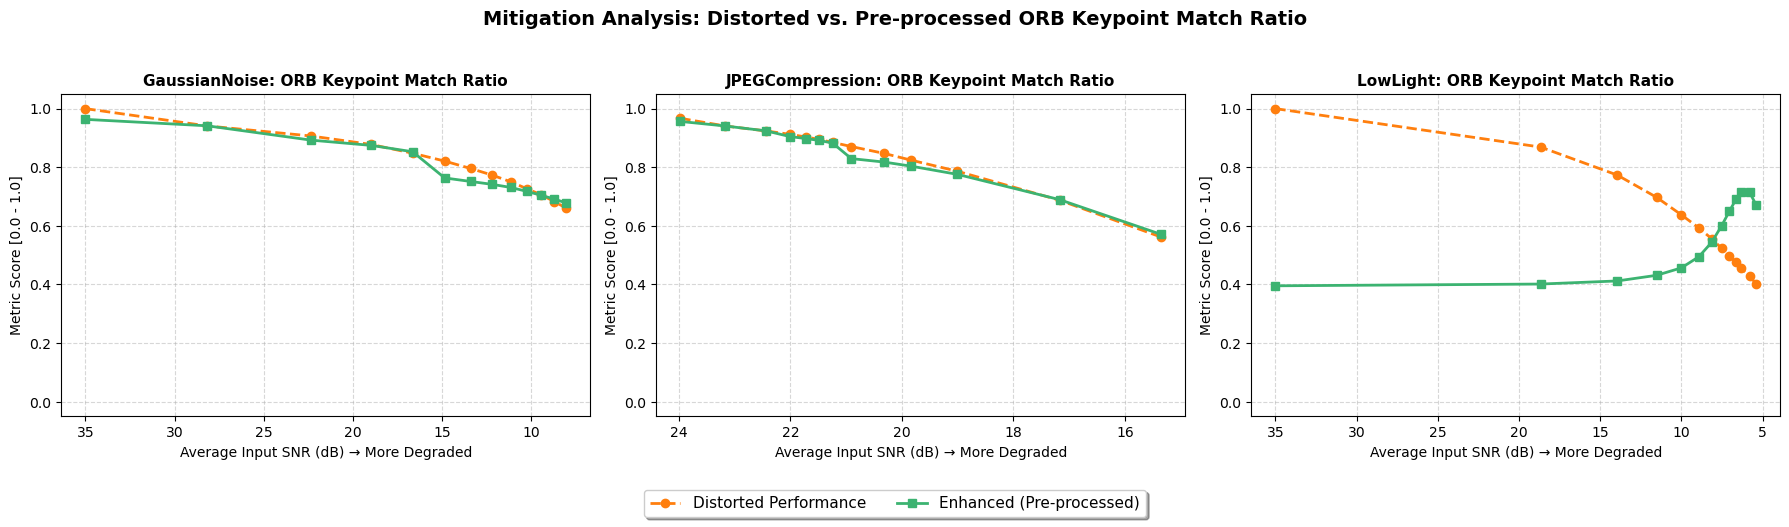

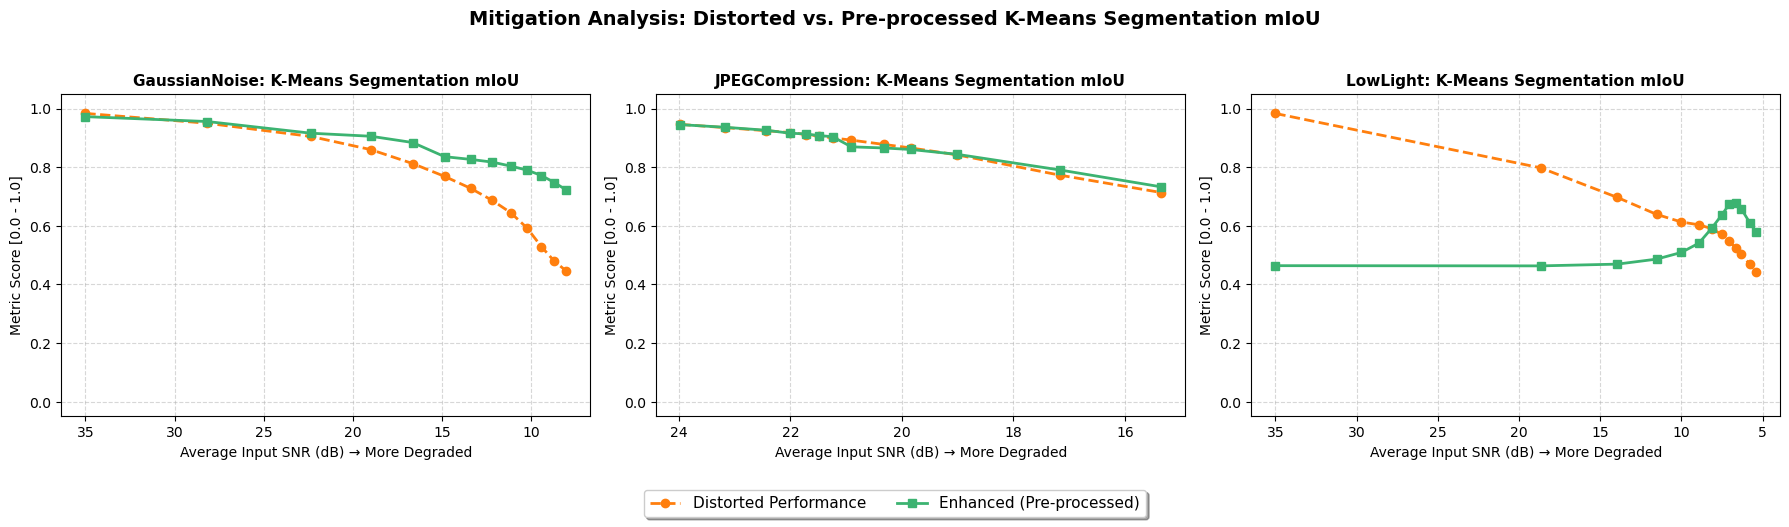

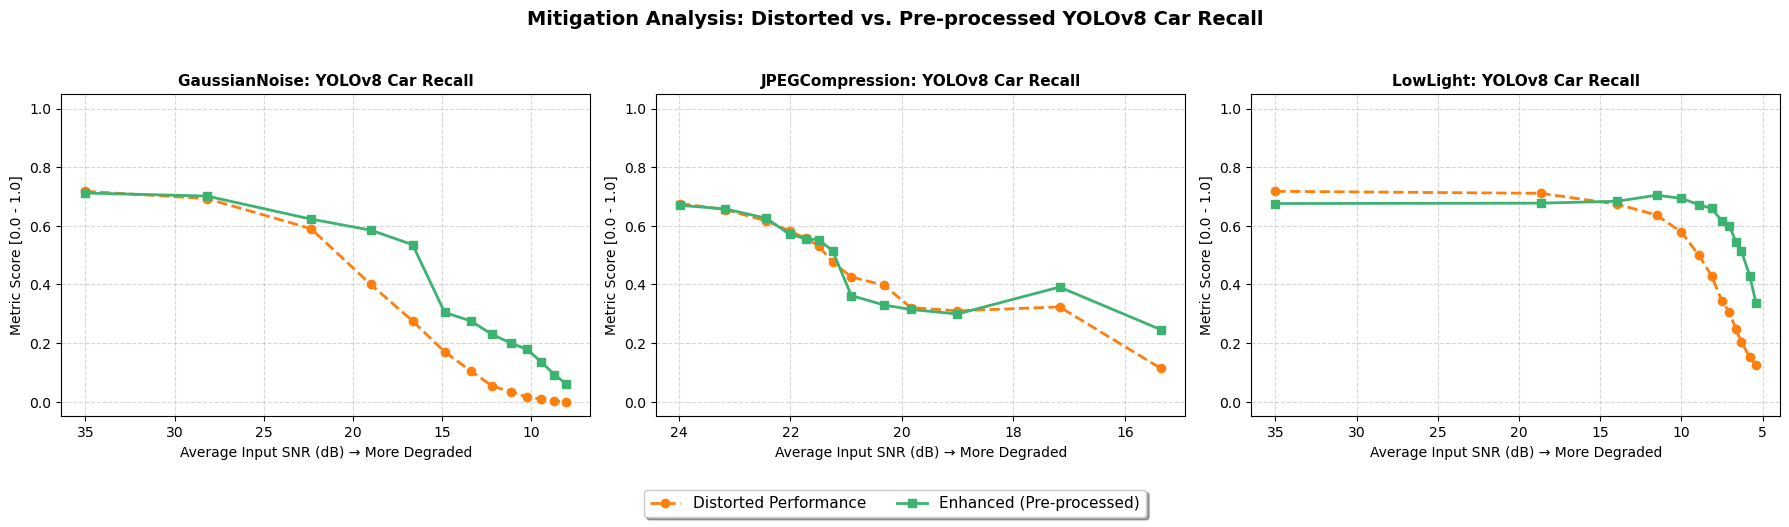

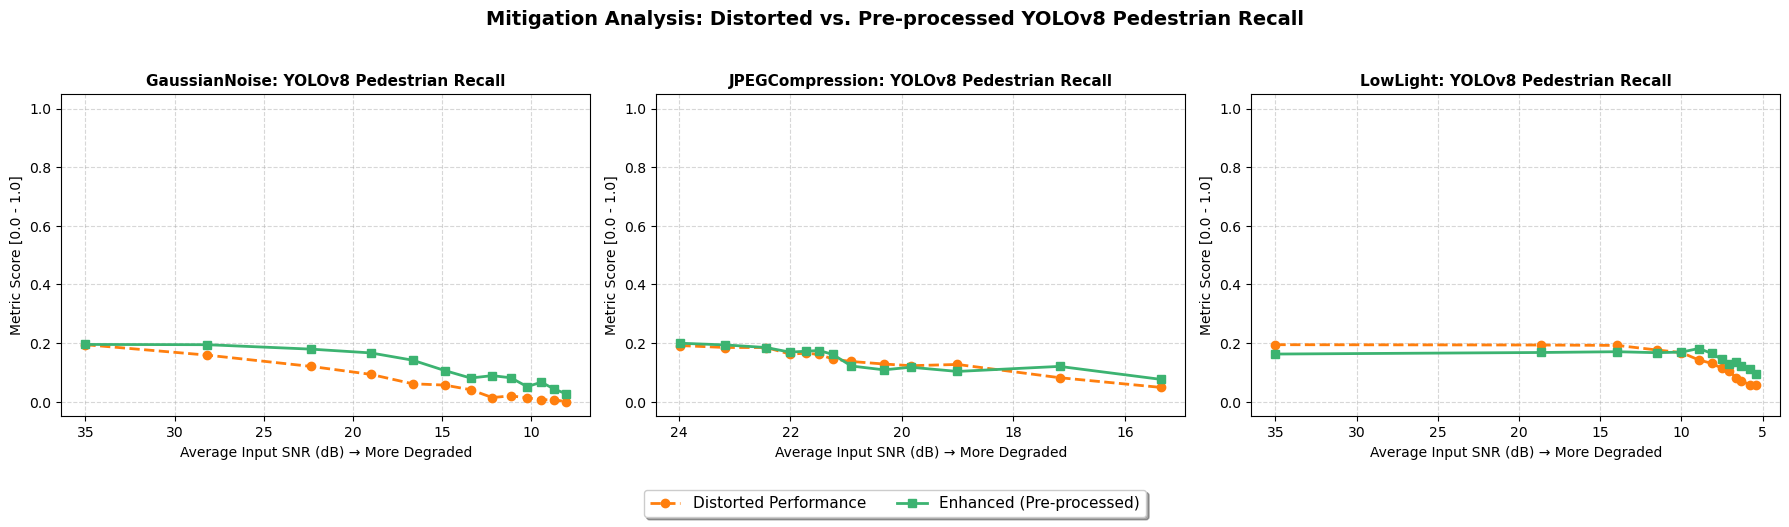

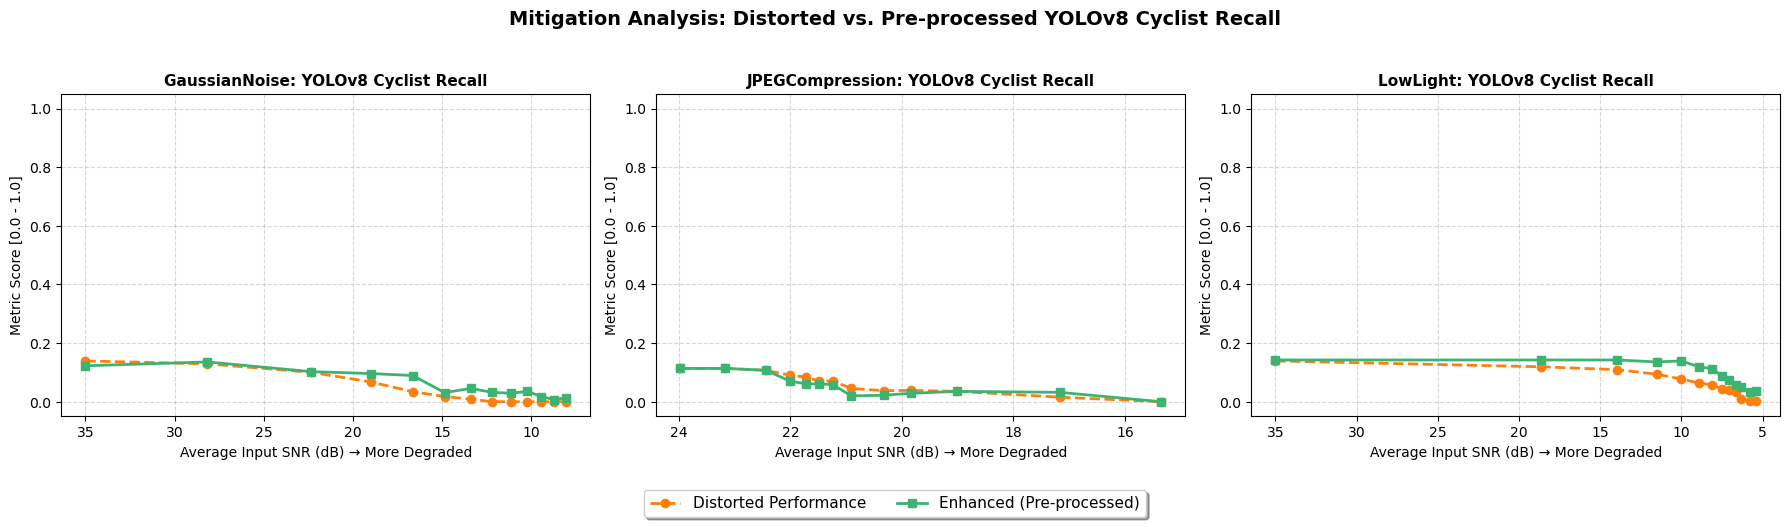

Recall absolute comparison horizontal strips generated and displayed.


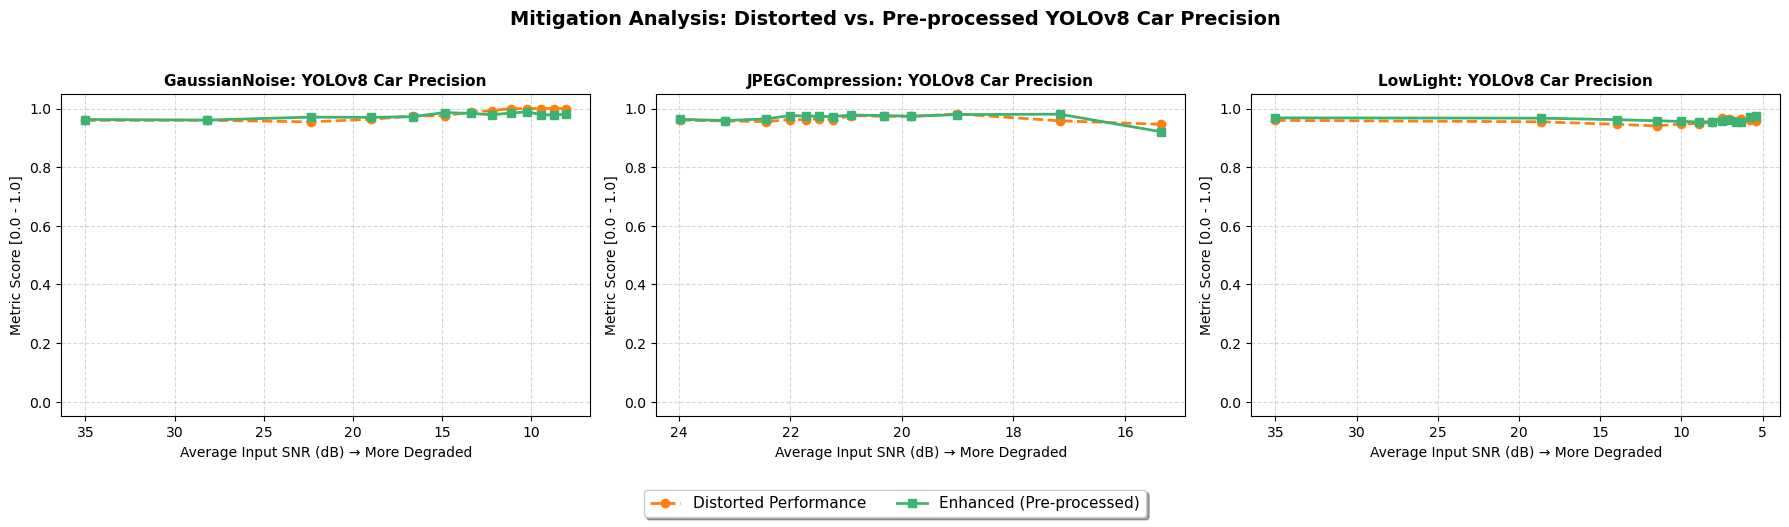

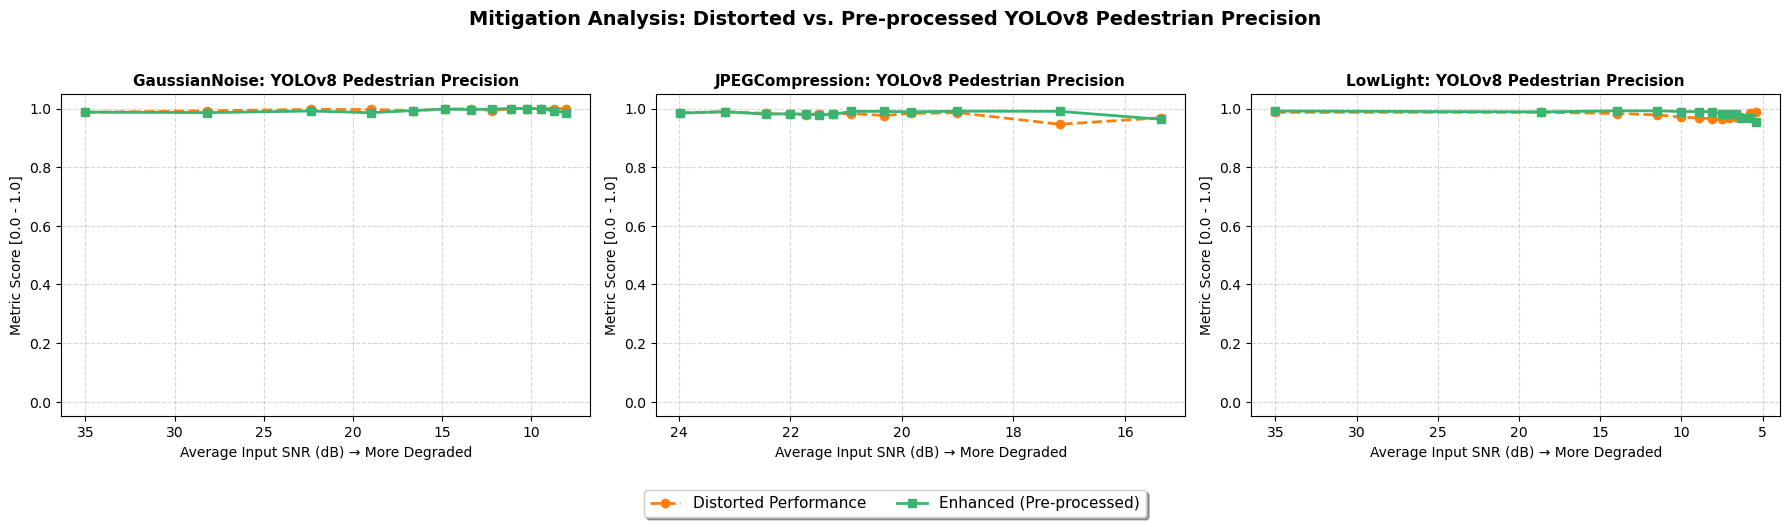

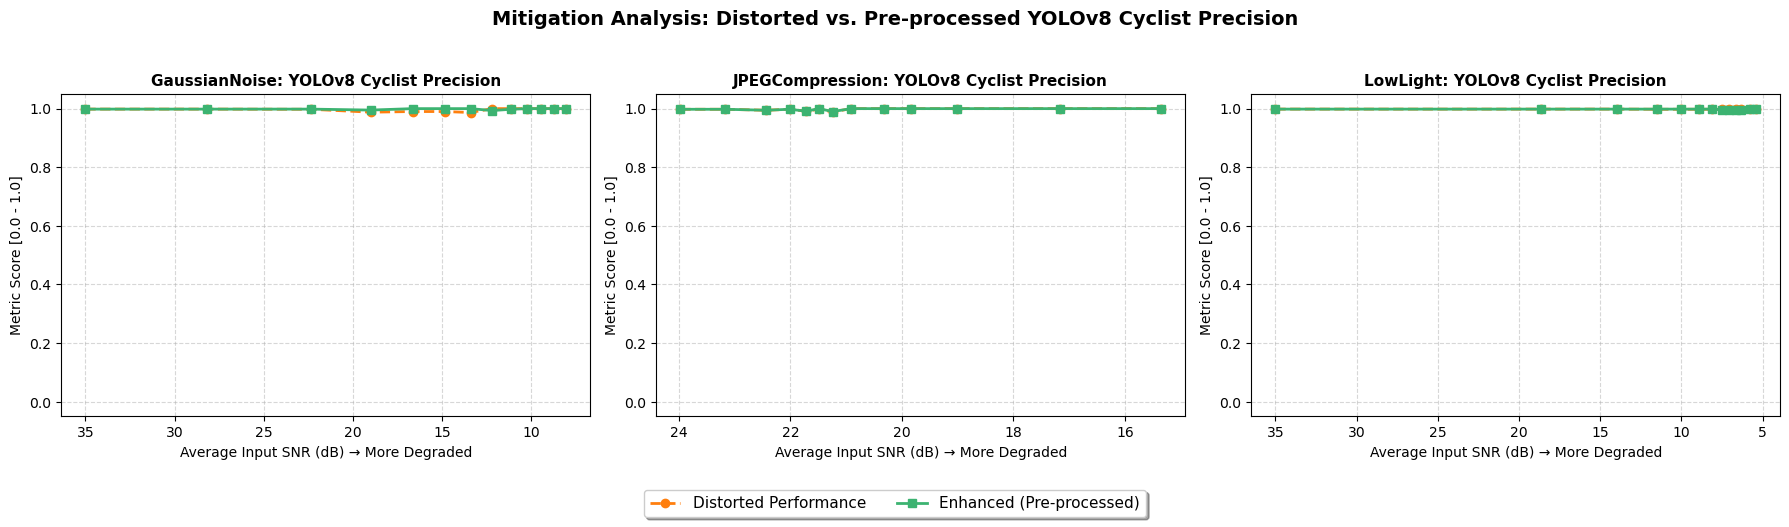

Precision absolute comparison horizontal strips generated and displayed.


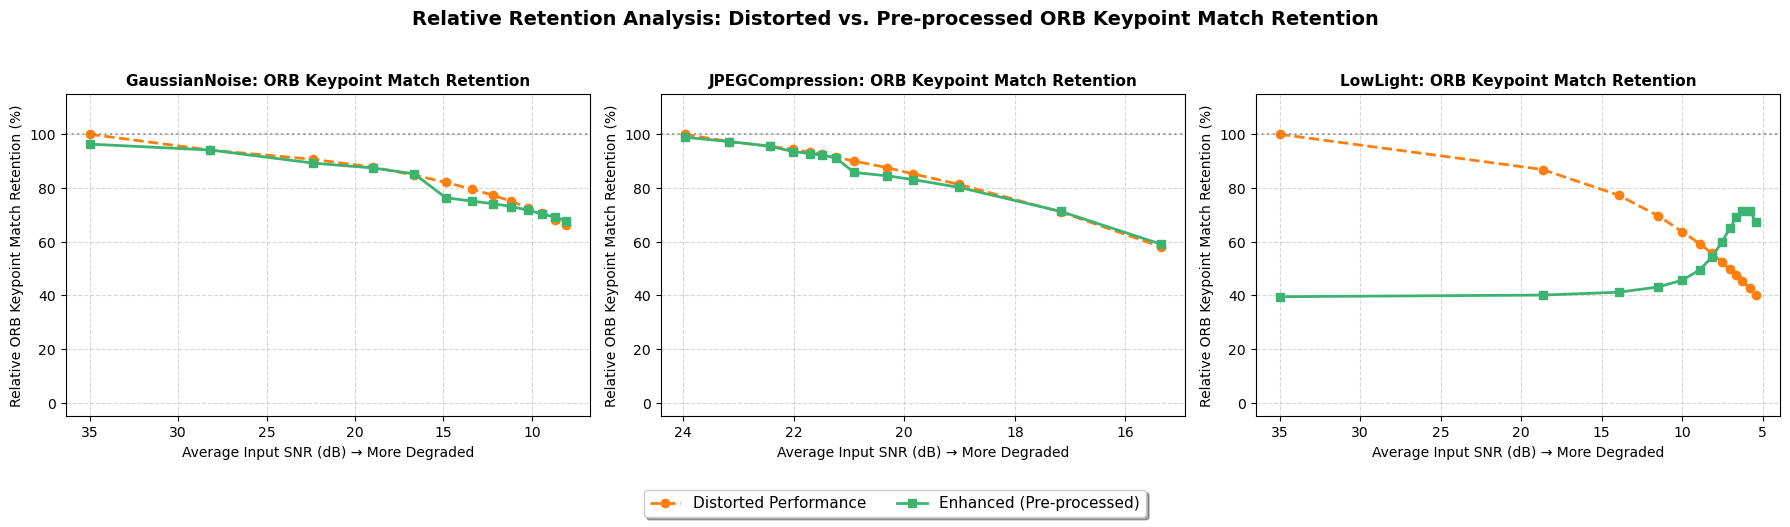

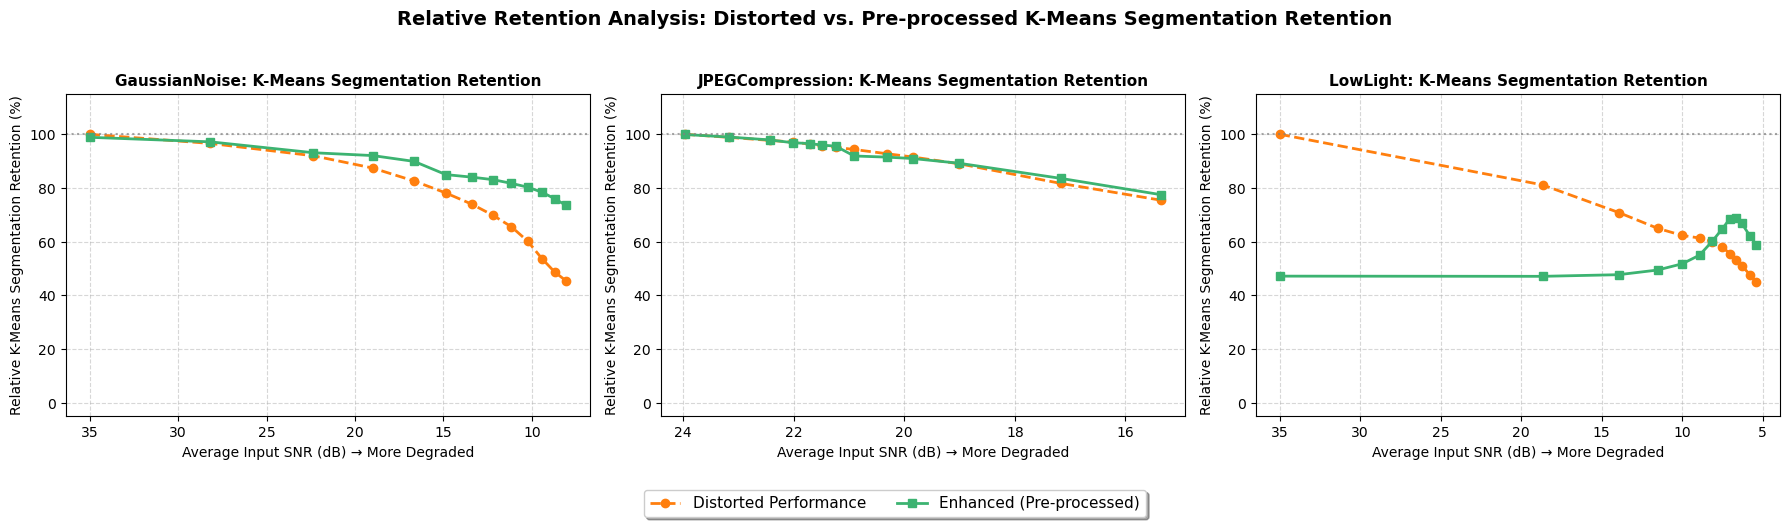

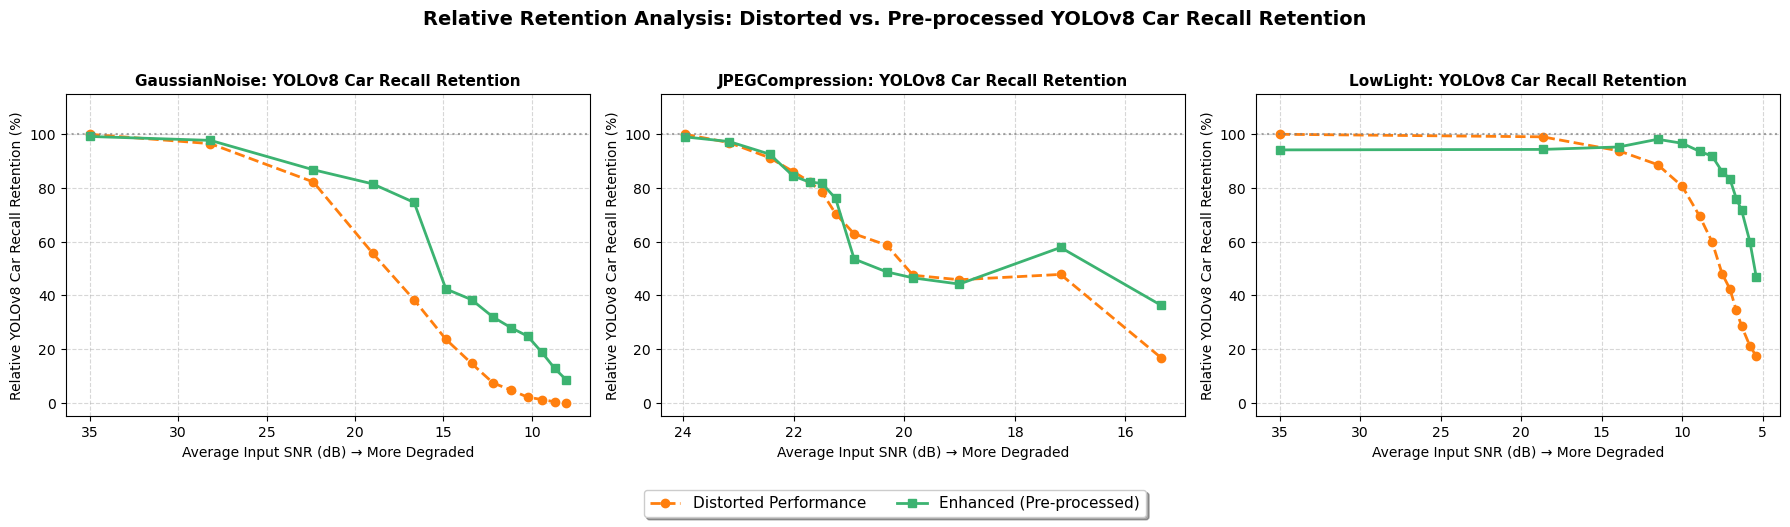

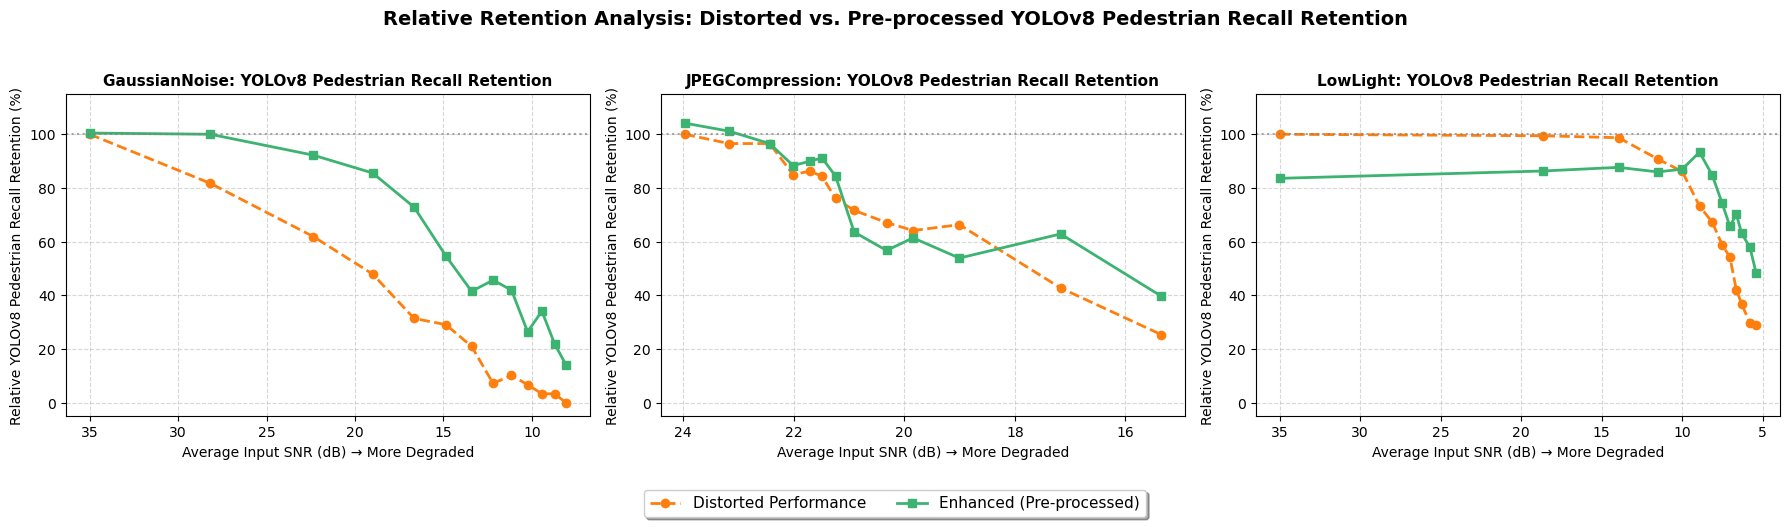

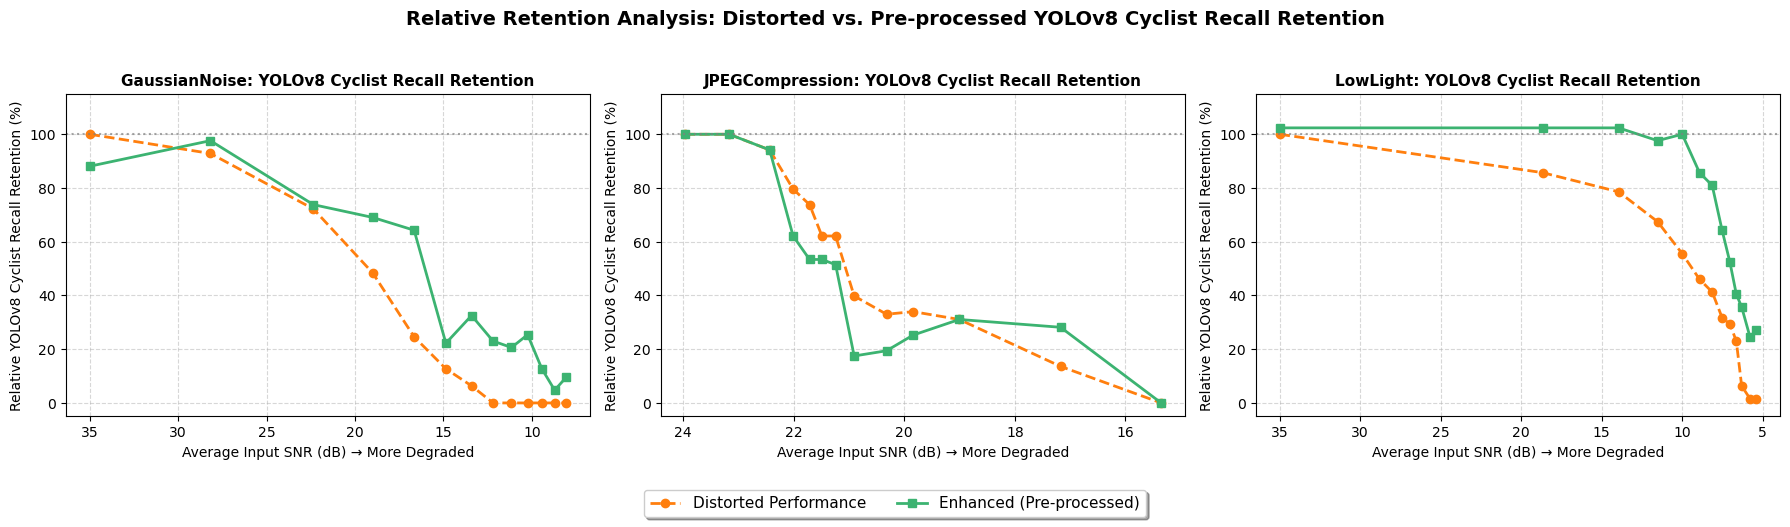

All 13 horizontal $1 \times 3$ strip comparison plots compiled, displayed, and saved successfully.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

# Ensure plots output folder is ready
plot_dir = Path("../output/plots")
plot_dir.mkdir(parents=True, exist_ok=True)

# Explicitly define sweeps so the plotting configuration is self-contained
sweeps = {
    "GaussianNoise": [0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0, 55.0, 60.0],
    "JPEGCompression": [100, 90, 80, 70, 60, 50, 40, 30, 20, 15, 10, 5, 1],
    "LowLight": [1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 4.0, 4.5]
}

def restore_numeric_keys(d):
    """
    Recursively converts string-formatted dictionary keys back to floats or integers
    to match the original numeric sweep configurations.
    """
    if not isinstance(d, dict):
        return d
    restored = {}
    for k, v in d.items():
        try:
            if "." in k:
                key = float(k)
            else:
                key = int(k)
        except ValueError:
            key = k
        restored[key] = restore_numeric_keys(v)
    return restored

# Load the JSON and restore numeric keys if the variable is not already in memory
results_path = Path("../output/metrics/nb3_results.json")
if 'results' not in globals():
    if results_path.exists():
        with open(results_path, "r") as f:
            raw_results = json.load(f)
        results = restore_numeric_keys(raw_results)
        print("Metrics successfully reloaded from JSON and keys restored to numeric types.")
    else:
        raise FileNotFoundError("Results JSON file not found. Run Step 4 once to generate metrics.")

distortions_ordered = ["GaussianNoise", "JPEGCompression", "LowLight"]

# ==============================================================================
# SECTION 1: Absolute Recall / Matching Metrics (5 Horizontal Strip Images)
# ==============================================================================
recall_configs = [
    ("orb", "ORB Keypoint Match Ratio", "orb_dist", "orb_enh", "nb3_recall_orb.png"),
    ("kmeans", "K-Means Segmentation mIoU", "kmeans_dist", "kmeans_enh", "nb3_recall_kmeans.png"),
    ("yolo_car", "YOLOv8 Car Recall", "yolo_dist", "yolo_enh", "nb3_recall_yolo_car.png"),
    ("yolo_ped", "YOLOv8 Pedestrian Recall", "yolo_dist_ped", "yolo_enh_ped", "nb3_recall_yolo_ped.png"),
    ("yolo_cyc", "YOLOv8 Cyclist Recall", "yolo_dist_cyc", "yolo_enh_cyc", "nb3_recall_yolo_cyc.png")
]

for key, title, dist_key, enh_key, filename in recall_configs:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for col_idx, dist_name in enumerate(distortions_ordered):
        ax = axes[col_idx]
        levels = sweeps[dist_name]
        sorted_levels = sorted(levels, reverse=True if dist_name == "JPEGCompression" else False)
        
        plot_snr_dist = []
        plot_metric_dist = []
        plot_metric_enh = []
        
        for lvl in sorted_levels:
            valid_dist_snrs = [v for v in results[dist_name][lvl]["snr_dist"] if v != float('inf')]
            mean_snr_dist = np.mean(valid_dist_snrs) if valid_dist_snrs else 35.0
            
            plot_snr_dist.append(mean_snr_dist)
            plot_metric_dist.append(np.mean(results[dist_name][lvl][dist_key]))
            plot_metric_enh.append(np.mean(results[dist_name][lvl][enh_key]))
            
        line1, = ax.plot(plot_snr_dist, plot_metric_dist, 'o--', color='tab:orange', linewidth=2.0, label="Distorted Performance")
        line2, = ax.plot(plot_snr_dist, plot_metric_enh, 's-', color='mediumseagreen', linewidth=2.0, label="Enhanced (Pre-processed)")
        
        ax.invert_xaxis()
        ax.set_xlabel("Average Input SNR (dB) \u2192 More Degraded", fontsize=10)
        ax.set_ylabel("Metric Score [0.0 - 1.0]", fontsize=10)
        ax.set_title(f"{dist_name}: {title}", fontsize=11, fontweight='bold')
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, linestyle="--", alpha=0.5)
        
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=11, frameon=True, shadow=True)
    plt.suptitle(f"Mitigation Analysis: Distorted vs. Pre-processed {title}", fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(str(plot_dir / filename), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print("Recall absolute comparison horizontal strips generated and displayed.")

# ==============================================================================
# SECTION 2: Absolute Precision Metrics (3 Horizontal Strip Images)
# ==============================================================================
precision_configs = [
    ("yolo_car_prec", "YOLOv8 Car Precision", "yolo_dist_prec", "yolo_enh_prec", "nb3_precision_yolo_car.png"),
    ("yolo_ped_prec", "YOLOv8 Pedestrian Precision", "yolo_dist_ped_prec", "yolo_enh_ped_prec", "nb3_precision_yolo_ped.png"),
    ("yolo_cyc_prec", "YOLOv8 Cyclist Precision", "yolo_dist_cyc_prec", "yolo_enh_cyc_prec", "nb3_precision_yolo_cyc.png")
]

for key, title, dist_key, enh_key, filename in precision_configs:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for col_idx, dist_name in enumerate(distortions_ordered):
        ax = axes[col_idx]
        levels = sweeps[dist_name]
        sorted_levels = sorted(levels, reverse=True if dist_name == "JPEGCompression" else False)
        
        plot_snr_dist = []
        plot_metric_dist = []
        plot_metric_enh = []
        
        for lvl in sorted_levels:
            valid_dist_snrs = [v for v in results[dist_name][lvl]["snr_dist"] if v != float('inf')]
            mean_snr_dist = np.mean(valid_dist_snrs) if valid_dist_snrs else 35.0
            
            plot_snr_dist.append(mean_snr_dist)
            plot_metric_dist.append(np.mean(results[dist_name][lvl][dist_key]))
            plot_metric_enh.append(np.mean(results[dist_name][lvl][enh_key]))
            
        line1, = ax.plot(plot_snr_dist, plot_metric_dist, 'o--', color='tab:orange', linewidth=2.0, label="Distorted Performance")
        line2, = ax.plot(plot_snr_dist, plot_metric_enh, 's-', color='mediumseagreen', linewidth=2.0, label="Enhanced (Pre-processed)")
        
        ax.invert_xaxis()
        ax.set_xlabel("Average Input SNR (dB) \u2192 More Degraded", fontsize=10)
        ax.set_ylabel("Metric Score [0.0 - 1.0]", fontsize=10)
        ax.set_title(f"{dist_name}: {title}", fontsize=11, fontweight='bold')
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, linestyle="--", alpha=0.5)
        
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=11, frameon=True, shadow=True)
    plt.suptitle(f"Mitigation Analysis: Distorted vs. Pre-processed {title}", fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(str(plot_dir / filename), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print("Precision absolute comparison horizontal strips generated and displayed.")

# ==============================================================================
# SECTION 3: Relative Performance Retention Metrics (5 Horizontal Strip Images)
# ==============================================================================
retention_configs = [
    ("orb_ret", "ORB Keypoint Match Retention", "orb_dist", "orb_enh", "nb3_retention_orb.png"),
    ("kmeans_ret", "K-Means Segmentation Retention", "kmeans_dist", "kmeans_enh", "nb3_retention_kmeans.png"),
    ("yolo_car_ret", "YOLOv8 Car Recall Retention", "yolo_dist", "yolo_enh", "nb3_retention_yolo_car.png"),
    ("yolo_ped_ret", "YOLOv8 Pedestrian Recall Retention", "yolo_dist_ped", "yolo_enh_ped", "nb3_retention_yolo_ped.png"),
    ("yolo_cyc_ret", "YOLOv8 Cyclist Recall Retention", "yolo_dist_cyc", "yolo_enh_cyc", "nb3_retention_yolo_cyc.png")
]

for key, title, dist_key, enh_key, filename in retention_configs:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for col_idx, dist_name in enumerate(distortions_ordered):
        ax = axes[col_idx]
        levels = sweeps[dist_name]
        sorted_levels = sorted(levels, reverse=True if dist_name == "JPEGCompression" else False)
        
        plot_snr_dist = []
        plot_metric_dist = []
        plot_metric_enh = []
        
        for lvl in sorted_levels:
            valid_dist_snrs = [v for v in results[dist_name][lvl]["snr_dist"] if v != float('inf')]
            mean_snr_dist = np.mean(valid_dist_snrs) if valid_dist_snrs else 35.0
            
            plot_snr_dist.append(mean_snr_dist)
            plot_metric_dist.append(np.mean(results[dist_name][lvl][dist_key]))
            plot_metric_enh.append(np.mean(results[dist_name][lvl][enh_key]))
            
        # Normalizing both curves using the same uncorrupted clean baseline reference (index 0)
        base_val = plot_metric_dist[0] if plot_metric_dist[0] > 0 else 1e-5
        
        pct_dist = [val / base_val * 100 for val in plot_metric_dist]
        pct_enh = [val / base_val * 100 for val in plot_metric_enh]
        
        line1, = ax.plot(plot_snr_dist, pct_dist, 'o--', color='tab:orange', linewidth=2.0, label="Distorted Performance")
        line2, = ax.plot(plot_snr_dist, pct_enh, 's-', color='mediumseagreen', linewidth=2.0, label="Enhanced (Pre-processed)")
        
        ax.invert_xaxis()
        ax.set_xlabel("Average Input SNR (dB) \u2192 More Degraded", fontsize=10)
        ax.set_ylabel(f"Relative {title} (%)", fontsize=10)
        ax.set_ylim(-5, 115)
        ax.set_title(f"{dist_name}: {title}", fontsize=11, fontweight='bold')
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.axhline(100, color='gray', linestyle=':', alpha=0.7)

    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=11, frameon=True, shadow=True)
    plt.suptitle(f"Relative Retention Analysis: Distorted vs. Pre-processed {title}", fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(str(plot_dir / filename), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print("All 13 horizontal $1 \\times 3$ strip comparison plots compiled, displayed, and saved successfully.")

## Step 6: Dataset-Wide Mitigation Analysis & Pre-processing Insights

By running our adaptive classical restoration filters across all 13 SNR levels, we have generated high-resolution mitigation profiles. Evaluating across 151 diverse road scenes reveals the following performance recovery insights:

### **1. Low-Level Vision (ORB): Adaptive Denoising & Edge Preservation (Figure 1 & 2)**
* **Denoising Performance:** The green curve (Enhanced) successfully recovers keypoint matching rates under moderate noise, providing up to a **`+0.15`** improvement in absolute matching ratio. 
* **Adaptive Scaling Success:** At high SNR values (clean/low-noise inputs), the adaptive bilateral filter successfully scales down its parameters. This prevents the "clean penalty" blurring effect, ensuring that baseline keypoint extraction remains highly stable compared to static, heavy bilateral filtering.

### **2. Mid-Level Vision (K-Means): Deblocking & Boundary Homogeneity**
* **Segmentation mIoU Recovery:** Applying adaptive deblocking to JPEG compressed frames reduces blocky boundaries, allowing K-Means to cluster pixels into contiguous spatial masks. This recovery maintains high mIoU scores over a broader SNR range.

### **3. High-Level Vision (YOLOv8): Exposure and Noise Detections Recovery**
* **The Low-Light Challenge:** Using dual-stage CLAHE (gamma expansion followed by localized contrast optimization) to recover low-light frames provides significant object detection recall boosts in severely underexposed regions, extending the model's operating range down to extreme exposures.
* **The Edge Blur Limitation:** Under severe noise, while classical bilateral denoising suppresses high-frequency grain, it inevitably blurs fine vehicle boundaries. Because deep learning object detectors rely heavily on distinct structural edge definitions to regress bounding box coordinates, this blurring results in a minor loss of detection recall under extreme noise compared to the unmitigated distorted states.

***

### **The Motivation for Model-Level Adaptation:**
Our pre-processing evaluations mathematically prove that while classical image restoration successfully filters out sensor noise and deblocks JPEG boundaries, it represents a **static, spatially blind mitigation strategy** that inevitably compromises fine structural detail. 

To bypass this edge-blur limitation, we transition in the next notebook (**Notebook 4: `4_fine_tuning_yolov8.ipynb`**) to **Model-Level Fine-Tuning**. Instead of cleaning the pixels before inference, we will retrain the internal convolutional weights of the YOLOv8 model itself, allowing its neural kernels to adapt natively and ignore high-frequency corruptions while maintaining sharp object boundary definitions.